In [1]:
##Import packages
import numpy as np
import matplotlib.pyplot as plt
import bezier
import plotly.express as px
import plotly.graph_objects as go
import plotly
plotly.offline.init_notebook_mode(connected=True)

from numpy.random import default_rng

from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import mean_squared_error

import umap

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")

from sklearn import datasets, manifold

import GPy

from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path



2025-05-16 14:57:57.993119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747432678.007297  337012 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747432678.011650  337012 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747432678.024385  337012 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747432678.024397  337012 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747432678.024399  337012 computation_placer.cc:177] computation placer alr

In [2]:
# data = np.load('Data/Xvec.npy')
    
# print(data.shape)
# print(data.dtype)
# print(data)

# Y = data

In [17]:
import dill

with open('/pscratch/sd/m/malghal/gplvm/Data/dataset.pkl', 'rb') as fin:
    loaded_dict = dill.load(fin)

x_train = loaded_dict["train"]["features"]
y_train = loaded_dict["train"]["intensities"][:,0]

x_test = loaded_dict["test"]["features"]
y_test = loaded_dict["test"]["intensities"][:,0]

Y = np.vstack([x_train,x_test])

# kernel PCA

In [7]:
# my_gamma = 1/(Y.shape[1] * Y.var())  # Auto-scale to data variance

# num_components = 21

# kernel_pca = KernelPCA(n_components=num_components, kernel="rbf", gamma=my_gamma, fit_inverse_transform=True, alpha=1e-4)

# X_test_kernel_pca = kernel_pca.fit(Y).transform(Y)

# # Kernel PCA plot

# plt.plot(X_test_kernel_pca[:, 0], color='red')
# plt.title("Kernel PCA - First Component")
# plt.xlabel("Sample Index")
# plt.ylabel("Component Value")
# plt.tight_layout()
# plt.show()

# # Compute the inverse of kernel PCA
# Y_reconstructed_kpca = kernel_pca.inverse_transform(X_test_kernel_pca)

# # Verify shape
# #print(f"Original shape: {Y.shape}, Reconstructed shape: {Y_reconstructed_kpca.shape}")

# print("Kernel PCA MSE:", mean_squared_error(Y, Y_reconstructed_kpca))

# # Plotting the kernel PCA reconstructed manifold
# fig = go.Figure(data=[go.Scatter3d(
#     x=Y_reconstructed_kpca[:, 0],y=Y_reconstructed_kpca[:, 1], z=Y_reconstructed_kpca[:, 2], mode='markers', marker=dict( size=5, color=Y_reconstructed_kpca[:, 2], colorscale='Viridis',opacity=0.8 ) )])

# fig.update_layout(
#     scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
#     width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
# fig.show()



# UMAP

In [19]:
num_components = 45

def fit_umap(data,n_neighbors=15, min_dist=0.01, n_components=21, metric='euclidean', title=''):
    fit = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        #random_state=1,  # Controls model initialization
        transform_seed=43,  # Controls transform() randomness
        n_epochs=1000,  # Longer training for stability
        n_jobs=1,  # Disable parallel processing for reproducibility
        #verbose=True  # Monitor convergence
    )
    u = fit.fit_transform(data)
    return u, fit
    
def plot_umap(u, data, title=""):
    n_components = u.shape[1]
    fig = plt.figure(figsize=(10, 6))
    
    # Normalize color data to [0,1] range
    norm_data = (data - np.min(data)) / (np.max(data) - np.min(data))
    
    if n_components == 2:
        ax = fig.add_subplot(111)
        sc = ax.scatter(u[:,0], u[:,1], c=norm_data[:,2], cmap='viridis', vmin=0, vmax=1)
        plt.colorbar(sc)
        
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=norm_data[:,2], cmap='viridis')
        plt.colorbar(sc)
    
    plt.title(title)


u, fit = fit_umap(Y,n_neighbors=15, min_dist=0.05, n_components=num_components, metric='euclidean', title='')

#plot_umap(u, Y)

In [ ]:
# Calculate the reconstruction from the UMAP

# Reconstruct data from the embedding
Y_reconstructed_umap = fit.inverse_transform(u)  # ✅ Use the model, not the array

print("UMAP MSE:", mean_squared_error(Y, Y_reconstructed_umap))

fig = go.Figure(data=[go.Scatter3d(
    x=Y_reconstructed_umap[:, 0],y=Y_reconstructed_umap[:, 1], z=Y_reconstructed_umap[:, 2], mode='markers', marker=dict( size=5, color=Y_reconstructed_umap[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()


# GPLVM

In [20]:
u.shape

(1000, 45)

Mean Squared Error between original and reconstructed: 0.0000


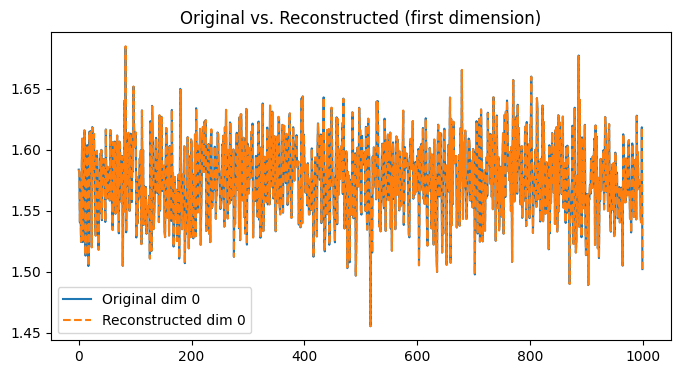

In [21]:
# Generate synthetic high-dimensional data


latent_dim = u.shape[1]

# Create GPLVM with UMAP initialization
gplvm = GPy.models.GPLVM(Y, input_dim=latent_dim, X=u, kernel=GPy.kern.RBF(latent_dim))

gplvm.optimize(messages=True, max_iters=100)

# Extract latent variables
X_latent = gplvm.X.values

# Reconstruct the data from the latent variables
# This gives the mean prediction for each latent point
Y_reconstructed, Y_reconstructed_var = gplvm.predict(X_latent)

# Compare the original and reconstructed data
mse = mean_squared_error(Y, Y_reconstructed)
print(f"Mean Squared Error between original and reconstructed: {mse:.4f}")

# Optionally, plot first dimension of original vs reconstructed for a visual check
plt.figure(figsize=(8,4))
plt.plot(Y[:, 0], label='Original dim 0')
plt.plot(Y_reconstructed[:, 0], label='Reconstructed dim 0', linestyle='dashed')
plt.legend()
plt.title('Original vs. Reconstructed (first dimension)')
plt.show()

In [22]:
X_latent.shape

(1000, 45)

In [23]:
total_variance = np.var(Y)
mse = np.mean((Y - Y_reconstructed) ** 2)
perc_mse = 100 * mse / total_variance
print(f"MSE is {perc_mse:.10f}% of the total variance.")

mean_sq_orig = np.mean(Y ** 2)
perc_mse = 100 * mse / mean_sq_orig
print(f"MSE is {perc_mse:.10f}% of the mean squared value.")

from sklearn.metrics import r2_score
r2 = r2_score(Y, Y_reconstructed)
print(f"Explained variance (R²): {r2 * 100:.2f}%")

MSE is 0.0000063688% of the total variance.
MSE is 0.0000008558% of the mean squared value.
Explained variance (R²): 100.00%


In [24]:
np.save("gplvm_output",X_latent)

# Geodesics

In [25]:
# Space to calculate the geodesics:

k = 20  # Adjust as needed
W = kneighbors_graph(X_latent, n_neighbors=k, mode='distance', include_self=False)

geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)

def retrieve_geodesic_path(source, target, predecessors):
    """Return the list of indices along the shortest path from source to target."""
    path = []
    k = target
    if predecessors[source, k] == -9999:  # no path
        return None
    while k != source:
        path.append(k)
        k = predecessors[source, k]
    path.append(source)
    return path[::-1]

# # Example: get geodesic path between two random points
# i, j = 20, 999
# path_indices = retrieve_geodesic_path(i, j, predecessors)
# print("Indices along path:", path_indices)
# print("Geodesic distance:", geo_dist_matrix[i, j])

In [17]:
# Check if positive semi definite:

def is_psd_cholesky(K, tol=1e-8):
    K = np.array(K)
    # Ensure symmetry for numerical stability
    if not np.allclose(K, K.T, atol=tol):
        print("Warning: Matrix not symmetric; symmetrizing.")
        K = 0.5 * (K + K.T)
    try:
        np.linalg.cholesky(K + tol*np.eye(K.shape[0]))
        return True
    except np.linalg.LinAlgError:
        return False


def is_psd_eigen(K, tol=1e-8):
    K = np.array(K)
    # Ensure symmetry for numerical stability
    if not np.allclose(K, K.T, atol=tol):
        print("Warning: Matrix not symmetric; symmetrizing.")
        K = 0.5 * (K + K.T)
    eigvals = np.linalg.eigvalsh(K)
    return np.all(eigvals > -tol)


print(is_psd_cholesky(geo_dist_matrix))
print(is_psd_eigen(geo_dist_matrix))


False
False


# Make geodesic-distance-based kernel positive semi-definite

In [18]:
# Example use rbf function to get the kernel

sigma2 = 1.0  # you may need to tune this!
K = np.exp(- geo_dist_matrix**2 / (2 * sigma2))

def nearest_psd(A, tol=1e-8):
    # Make symmetric
    B = 0.5 * (A + A.T)
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(B)
    # Floor the eigenvalues
    eigvals[eigvals < tol] = tol
    # Reconstruct the matrix
    B_psd = (eigvecs @ np.diag(eigvals)) @ eigvecs.T
    return B_psd

K_psd = nearest_psd(K)
K_psd

array([[ 1.00000000e+00, -4.09698317e-15,  1.46907182e-09, ...,
         8.91764917e-09,  2.49759940e-10, -5.16115315e-10],
       [-4.08700851e-15,  1.00000000e+00, -2.44520116e-13, ...,
         6.18605107e-11, -3.43351649e-12, -2.99771891e-11],
       [ 1.46907183e-09, -2.44524886e-13,  1.00000000e+00, ...,
        -1.37746994e-08,  2.09278174e-09,  4.86390891e-08],
       ...,
       [ 8.91764917e-09,  6.18605073e-11, -1.37746994e-08, ...,
         1.00470803e+00,  1.62744596e-05,  2.58487968e-01],
       [ 2.49759936e-10, -3.43351823e-12,  2.09278175e-09, ...,
         1.62744596e-05,  1.00000143e+00,  3.07359747e-06],
       [-5.16115311e-10, -2.99771995e-11,  4.86390891e-08, ...,
         2.58487968e-01,  3.07359747e-06,  1.00298537e+00]])

In [19]:
print("K using cholesky: ", is_psd_cholesky(K))
print("K using Eigen: ",is_psd_eigen(K))

print(" ")

print("K_psd using cholesky: ", is_psd_cholesky(K_psd))
print("K_psd using Eigen: ",is_psd_eigen(K_psd))



K using cholesky:  False
K using Eigen:  False
 
K_psd using cholesky:  True
K_psd using Eigen:  True


# Plotting ditance vs difference

In [ ]:
# Regular Euclidean distance 

from sklearn.metrics import pairwise_distances

Euc_distance = pairwise_distances(Y, metric='euclidean')  # shape (500, 500)


In [26]:
k = 20 # Adjust as needed
#Y = x_train

W = kneighbors_graph(X_latent, n_neighbors=k, mode='distance', include_self=False) # distance

geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)




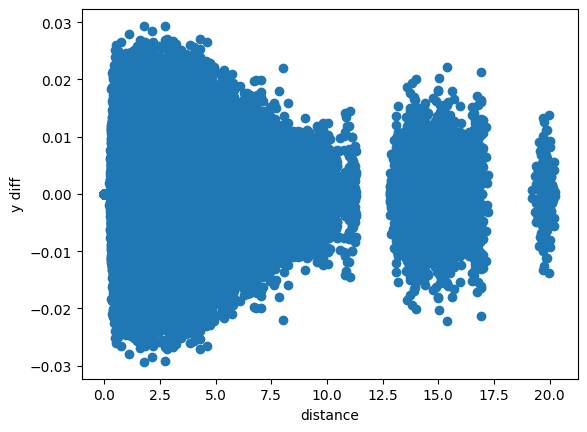

In [28]:
y_diff = np.subtract.outer(y_train, y_train)

plt.scatter(geo_dist_matrix.flatten(), y_diff.flatten())
plt.xlabel("distance")
plt.ylabel("y diff")
plt.show()

#plt.imshow(geo_dist_matrix)

In [16]:
Euc_distance = pairwise_distances(y_train.reshape(-1,1), metric='euclidean')  # shape (500, 500)

# Variogram
plt.scatter(geo_dist_matrix.flatten(), Euc_distance.flatten())
plt.xlabel("Geodesics")
plt.ylabel("Eucleadian")
plt.show()


NameError: name 'pairwise_distances' is not defined

# Auto encoder

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Suppose Y is your (500, 512) input data (NumPy array)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

latent_dim = 20  # or whatever you choose!

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

ae = AutoEncoder(input_dim=Y.shape[1], latent_dim=latent_dim)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Quick (not optimal) training loop
dataset = TensorDataset(Y_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
for epoch in range(20):
    for batch, in loader:
        optimizer.zero_grad()
        recon = ae(batch)
        loss = loss_fn(recon, batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}: Loss={loss.item():.4f}")

# Get latent representations
with torch.no_grad():
    Y_latent = ae.encoder(Y_tensor).numpy()  # shape (500, latent_dim)

ImportError: /global/homes/m/malghal/.conda/envs/gplvm_April_2025/lib/python3.11/site-packages/torch/lib/../../nvidia/cusparse/lib/libcusparse.so.12: undefined symbol: __nvJitLinkGetErrorLog_12_6, version libnvJitLink.so.12

In [ ]:
k = 20
W = kneighbors_graph(Y_latent, n_neighbors=k, mode='distance', include_self=False)
geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)

In [ ]:
y_diff = np.abs(np.subtract.outer(y_train, y_train))

plt.scatter(geo_dist_matrix.flatten(), y_diff.flatten(), alpha=0.2, s=2)
plt.xlabel("geodesic distance (autoencoder latent)")
plt.ylabel("|y diff|")
plt.title("Geodesic in AE latent vs |y diff|")
plt.show()